# ThyroidXL Dataset Overview and Stage Preparation

This notebook starts with a full dataset visualization before model training.
It inspects the original ThyroidXL labels, prints class counts, plots class balance,
shows representative image samples, and sets up the Stage 1 and Stage 2 training workflow.

Project goal:
- Stage 1: Benign vs Malignant
- Stage 2: PTC vs NonPTC
- Final output: Benign / PTC / NonPTC

In [1]:
from pathlib import Path
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

root = Path("data/ThyroidXL")
train_json = root / "train" / "train_annotations.json"
test_json = root / "test" / "test_annotations.json"

print("Dataset root:", root)
print("Train annotations:", train_json.exists())
print("Test annotations:", test_json.exists())

for path in [train_json, test_json]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    print("\nFILE:", path)
    print("Keys:", list(data.keys()))
    print("Num images:", len(data.get("images", [])))
    print("Num annotations:", len(data.get("annotations", [])))
    print("Num patient records:", len(data.get("info", {})))

Dataset root: data\ThyroidXL
Train annotations: True
Test annotations: True

FILE: data\ThyroidXL\train\train_annotations.json
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Num images: 9541
Num annotations: 9541
Num patient records: 3354

FILE: data\ThyroidXL\test\test_annotations.json
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Num images: 2094
Num annotations: 2094
Num patient records: 739


## 1) Load and inspect the full dataset

This section verifies the dataset structure and image/annotation metadata before summarizing the class labels.

In [2]:
PTC_TERMS = {
    "papillary thyroid carcinoma",
    "micro-papillary thyroid carcinoma",
    "papillary thyroid carcinoma, chronic thyroiditis",
}
NON_PTC_TERMS = {
    "follicular thyroid carcinoma",
    "medullary thyroid carcinoma",
    "hurthle cell carcinoma",
    "follicular thyroid tumor",
    "anaplastic",
    "carcinoma",
    "malignant",
    "thyroiditis",
    "cancer",
}
BENIGN_TERMS = {
    "thyroid cyst disease",
    "colloid nodule",
    "follicular thyroid adenoma",
    "hurthle cell adenoma",
    "adenoma",
    "benign",
}

LABEL_MAP = {
    0: "PTC",
    1: "NonPTC",
    2: "Benign",
}


def clean(v):
    return str(v or "").strip().lower()


def infer_label(record):
    for key in ["nodule_1", "nodule_2"]:
        nodule = record.get(key) or {}
        hist = clean(nodule.get("Histopathology"))
        conclusion = clean(nodule.get("Conclusion"))
        if hist and any(term in hist for term in PTC_TERMS):
            return 0
        if hist and any(term in hist for term in NON_PTC_TERMS):
            return 1
        if hist and any(term in hist for term in BENIGN_TERMS):
            return 2
        if "benign" in conclusion:
            return 2
        if "malignant" in conclusion or "carcinoma" in conclusion:
            return 1
    return 2

# Load train and test records
for split_name, path in [("train", train_json), ("test", test_json)]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    records = []
    for patient_id, record in data.get("info", {}).items():
        label = infer_label(record)
        records.append({
            "patient_id": patient_id,
            "label_id": label,
            "label_name": LABEL_MAP[label],
            "n_images": len(record.get("images", [])),
        })
    df = pd.DataFrame(records)
    print(f"\n{split_name.upper()} label counts:")
    print(df["label_name"].value_counts().reindex(["PTC", "NonPTC", "Benign"], fill_value=0))


TRAIN label counts:
label_name
PTC        506
NonPTC     376
Benign    2472
Name: count, dtype: int64

TEST label counts:
label_name
PTC       194
NonPTC    158
Benign    387
Name: count, dtype: int64


## 2) Map labels to category IDs and names

The original dataset categories are mapped to the project’s three-class target space:
- 0 = PTC
- 1 = NonPTC
- 2 = Benign

In [3]:
label_table = pd.DataFrame([
    {"class_id": 0, "class_name": "PTC", "stage1_name": "Malignant", "stage2_name": "PTC"},
    {"class_id": 1, "class_name": "NonPTC", "stage1_name": "Malignant", "stage2_name": "NonPTC"},
    {"class_id": 2, "class_name": "Benign", "stage1_name": "Benign", "stage2_name": "Ignored"},
])
label_table

,class_id,class_name,stage1_name,stage2_name
0,0,PTC,Malignant,PTC
1,1,NonPTC,Malignant,NonPTC
2,2,Benign,Benign,Ignored


## 3) Count samples per label and category

This section aggregates the total sample counts and highlights imbalance across the full dataset.

In [13]:
df.head(10)

,split,patient_id,label_id,label_name,n_images
0,train,00000058,2,Benign,2
1,train,00000127,2,Benign,3
2,train,00000140,2,Benign,3
3,train,00000141,2,Benign,4
4,train,00000162,2,Benign,2
5,train,00000176,2,Benign,3
6,train,00000182,2,Benign,2
7,train,00000196,2,Benign,7
8,train,00000199,2,Benign,4
9,train,00000204,2,Benign,2


In [15]:
all_rows = []
for split_name, path in [("train", train_json), ("test", test_json)]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    for patient_id, record in data.get("info", {}).items():
        label = infer_label(record)
        all_rows.append({
            "split": split_name,
            "patient_id": patient_id,
            "label_id": label,
            "label_name": LABEL_MAP[label],
            "n_images": len(record.get("images", [])),
        })

df = pd.DataFrame(all_rows)
print("Total patient records:", len(df))
print("Total image counts:", df["n_images"].sum())
print("\nWhole dataset label counts:")
print(df["label_name"].value_counts().reindex(["PTC", "NonPTC", "Benign"], fill_value=0))

# Full count table
summary = df.groupby("label_name").agg(
    patients=("patient_id", "count"),
    images=("n_images", "sum"),
    avg_images_per_patient=("n_images", "mean"),
).reindex(["PTC", "NonPTC", "Benign"]) 
summary["percent_of_patients"] = summary["patients"] / summary["patients"].sum() * 100
summary

# Count the number of images per category in training and validation sets and plot the distribution
train_dataset = df[df["split"] == "train"]
test_dataset = df[df["split"] == "test"]

train_images = train_dataset.groupby('label_name')['n_images'].sum()
test_images = test_dataset.groupby('label_name')['n_images'].sum()

print("\nTraining set image counts:")
print(train_images)
print("\nTest set image counts:")
print(test_images)

Total patient records: 4093
Total image counts: 11635

Whole dataset label counts:
label_name
PTC        700
NonPTC     534
Benign    2859
Name: count, dtype: int64

Training set image counts:
label_name
Benign    7038
NonPTC    1067
PTC       1436
Name: n_images, dtype: int64

Test set image counts:
label_name
Benign    1122
NonPTC     435
PTC        537
Name: n_images, dtype: int64


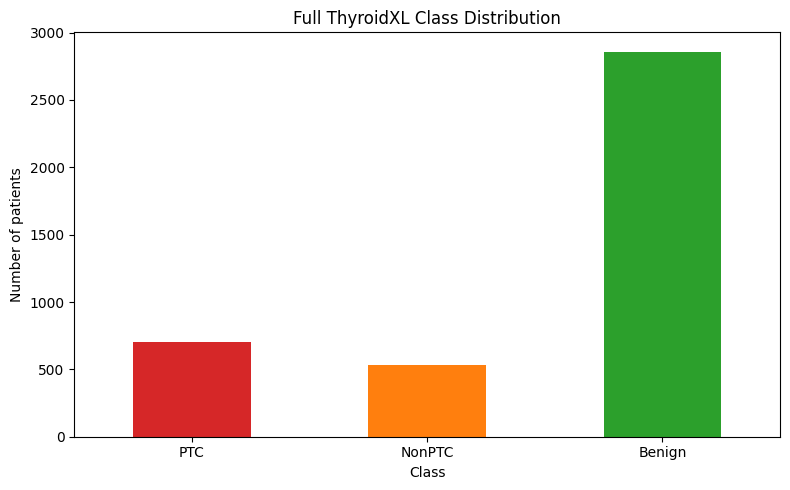

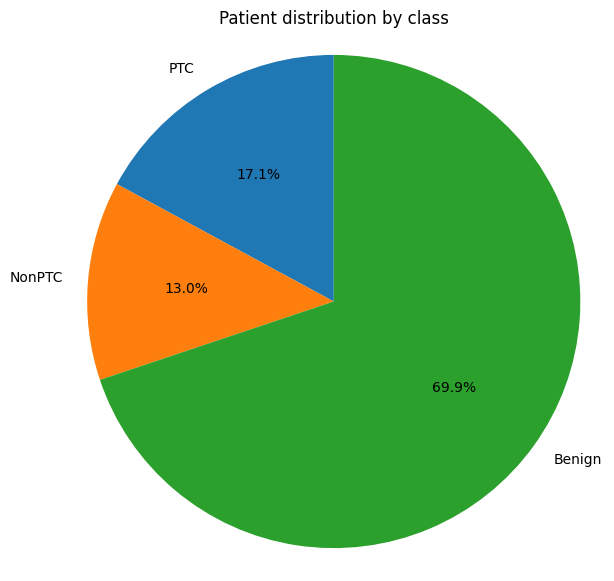

In [5]:
# Bar chart for the full class distribution
summary_plot = df["label_name"].value_counts().reindex(["PTC", "NonPTC", "Benign"], fill_value=0)

plt.figure(figsize=(8, 5))
summary_plot.plot(kind="bar", color=["#d62728", "#ff7f0e", "#2ca02c"])
plt.title("Full ThyroidXL Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.pie(summary_plot.values, labels=summary_plot.index, autopct="%1.1f%%", startangle=90)
plt.title("Patient distribution by class")
plt.axis("equal")
plt.show()

In [ ]:
# Calculate the number of images per category in training and validation sets and plot the distribution
train_counts = train_dataset.groupby('category').size()
validation_counts = validation_dataset.groupby('category').size()


## 4) Show sample images for each label

This section picks a few representative examples from each class and displays them with their category names.


=== PTC samples ===
00000256_05378729_0.png


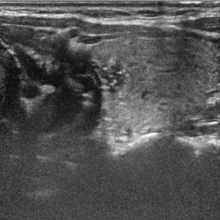

00000370_86B8B3BE_0.png


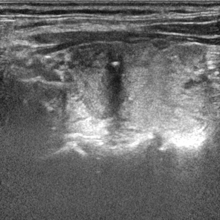

00000509_27EE406D_1.png


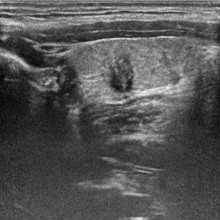


=== NonPTC samples ===
00001548_6A567CD3_2.png


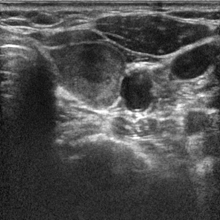

00003919_A2C598B6_0.png


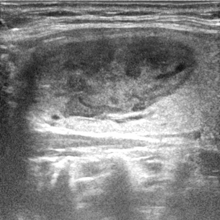

00000132_3D938012_2.png


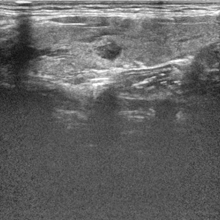


=== Benign samples ===
00000058_2201CE11_0.png


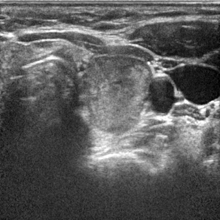

00000127_1914A778_1.png


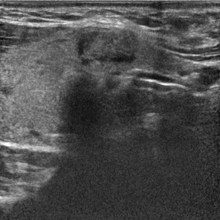

00000140_ABD9A36A_2.png


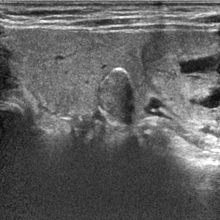

In [6]:
from PIL import Image
from IPython.display import display

sample_paths = {
    "PTC": [],
    "NonPTC": [],
    "Benign": [],
}

# Gather one representative image per patient when possible
for split_name, path in [("train", train_json), ("test", test_json)]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    image_lookup = {img["id"]: img for img in data.get("images", [])}
    for patient_id, record in data.get("info", {}).items():
        label_name = LABEL_MAP[infer_label(record)]
        for image_name in record.get("images", [])[:1]:
            if len(sample_paths[label_name]) < 3:
                sample_paths[label_name].append(root / split_name / "images" / image_name)

for label, paths in sample_paths.items():
    print(f"\n=== {label} samples ===")
    for img_path in paths:
        if img_path.exists():
            img = Image.open(img_path)
            print(img_path.name)
            display(img.resize((220, 220)))
        else:
            print("Missing:", img_path)

## 5) Inspect imbalance and stratification risk

The dataset is not perfectly balanced. This matters because Stage 1 reduces the problem to Benign vs Malignant, while Stage 2 focuses only on malignant cases.

In [7]:
# Summary of imbalance ratios
counts = df["label_name"].value_counts().reindex(["PTC", "NonPTC", "Benign"], fill_value=0)
counts_df = pd.DataFrame({
    "count": counts.values,
    "share_percent": counts.values / counts.values.sum() * 100,
}, index=counts.index)
counts_df

,count,share_percent
label_name,,
PTC,700,17.102370
NonPTC,534,13.046665
Benign,2859,69.850965


## 6) Prepare the dataset for training

This notebook ends by setting up the training-ready structures used in the next stage.

In [8]:
from sklearn.model_selection import train_test_split

# A simple patient-level split stub, consistent with the project requirement:
# - split once
# - keep the same patient IDs for both stages
# - relabel after split

patient_table = []
for split_name, path in [("train", train_json), ("test", test_json)]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    for patient_id, record in data.get("info", {}).items():
        patient_table.append({
            "patient_id": patient_id,
            "split": split_name,
            "label_id": infer_label(record),
            "label_name": LABEL_MAP[infer_label(record)],
        })

patient_df = pd.DataFrame(patient_table)
print("Patient-level table snapshot:")
patient_df.head()

# Example split configuration for the next stage.
# The actual Stage 1 / Stage 2 training data will be generated in the project-specific dataset script.
stage1_config = {
    "task": "Benign vs Malignant",
    "classes": {0: "Benign", 1: "Malignant"},
    "train": "data/ThyroidXL_two_stage/stage1/images/train",
    "val": "data/ThyroidXL_two_stage/stage1/images/val",
    "test": "data/ThyroidXL_two_stage/stage1/images/test",
}

stage2_config = {
    "task": "PTC vs NonPTC",
    "classes": {0: "PTC", 1: "NonPTC"},
    "train": "data/ThyroidXL_two_stage/stage2/images/train",
    "val": "data/ThyroidXL_two_stage/stage2/images/val",
    "test": "data/ThyroidXL_two_stage/stage2/images/test",
}

print("\nStage 1 config:", stage1_config)
print("\nStage 2 config:", stage2_config)

Patient-level table snapshot:

Stage 1 config: {'task': 'Benign vs Malignant', 'classes': {0: 'Benign', 1: 'Malignant'}, 'train': 'data/ThyroidXL_two_stage/stage1/images/train', 'val': 'data/ThyroidXL_two_stage/stage1/images/val', 'test': 'data/ThyroidXL_two_stage/stage1/images/test'}

Stage 2 config: {'task': 'PTC vs NonPTC', 'classes': {0: 'PTC', 1: 'NonPTC'}, 'train': 'data/ThyroidXL_two_stage/stage2/images/train', 'val': 'data/ThyroidXL_two_stage/stage2/images/val', 'test': 'data/ThyroidXL_two_stage/stage2/images/test'}


## 7) Stage 1 training setup

The next stage will train a benign-vs-malignant model using the remapped stage-level labels and the shared patient split.

In [9]:
stage1 = {
    "model": "yolo11n-seg.pt",
    "dataset_yaml": "data/ThyroidXL_two_stage/stage1/stage1.yaml",
    "task": "segment",
    "classes": {0: "Benign", 1: "Malignant"},
    "epochs": 100,
    "batch_size": 8,
    "imgsz": 640,
    "optimizer": "AdamW",
    "lr": 0.001,
}
stage1

{'model': 'yolo11n-seg.pt',
 'dataset_yaml': 'data/ThyroidXL_two_stage/stage1/stage1.yaml',
 'task': 'segment',
 'classes': {0: 'Benign', 1: 'Malignant'},
 'epochs': 100,
 'batch_size': 8,
 'imgsz': 640,
 'optimizer': 'AdamW',
 'lr': 0.001}

## 8) Stage 2 training setup

Stage 2 will train a PTC-vs-NonPTC model only on malignant cases from the same split, using the fixed patient IDs from the earlier split.

In [10]:
stage2 = {
    "model": "yolo11n-cls.pt",
    "dataset_yaml": "data/ThyroidXL_two_stage/stage2/stage2.yaml",
    "task": "classify",
    "classes": {0: "PTC", 1: "NonPTC"},
    "epochs": 80,
    "batch_size": 16,
    "imgsz": 224,
    "optimizer": "AdamW",
    "lr": 0.0005,
}
stage2

{'model': 'yolo11n-cls.pt',
 'dataset_yaml': 'data/ThyroidXL_two_stage/stage2/stage2.yaml',
 'task': 'classify',
 'classes': {0: 'PTC', 1: 'NonPTC'},
 'epochs': 80,
 'batch_size': 16,
 'imgsz': 224,
 'optimizer': 'AdamW',
 'lr': 0.0005}

## 9) Summary

This notebook completes the full dataset inspection and creates the training-ready stage configuration for the next step.
The next object is to train Stage 1, then Stage 2, and finally fuse probabilities into Benign / PTC / NonPTC.